In [13]:
# Standard library
import gc
import warnings
from typing import Union, Optional, Tuple, List, Dict, Any
from pathlib import Path
import pickle
import base64

# Core data science
import numpy as np
import pandas as pd

# Scikit-learn
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error

from PIL import Image
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

DATA_DIR = Path("/share/crsp/lab/pkaiser/ddlin/single-cell-multimodal-ml/data")
RAW_DIR = DATA_DIR.joinpath("raw")
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

FP_CITE_TRAIN_INPUTS  = RAW_DIR.joinpath("train_cite_inputs.h5")
FP_CITE_TRAIN_TARGETS = RAW_DIR.joinpath("train_cite_targets.h5")
FP_CITE_TEST_INPUTS   = RAW_DIR.joinpath("test_cite_inputs.h5")

FP_IMPORTANT_COLS = PROCESSED_DIR.joinpath("important_cols.txt")
FP_CONSTANT_COLS = PROCESSED_DIR.joinpath("constant_cols.txt")


FP_EVALUATION_IDS     = RAW_DIR.joinpath("evaluation_ids.csv")
FP_CELL_METADATA      = RAW_DIR.joinpath("metadata.csv")

VERBOSE = 0

## Keras for single cell CITE-seq & Multiome

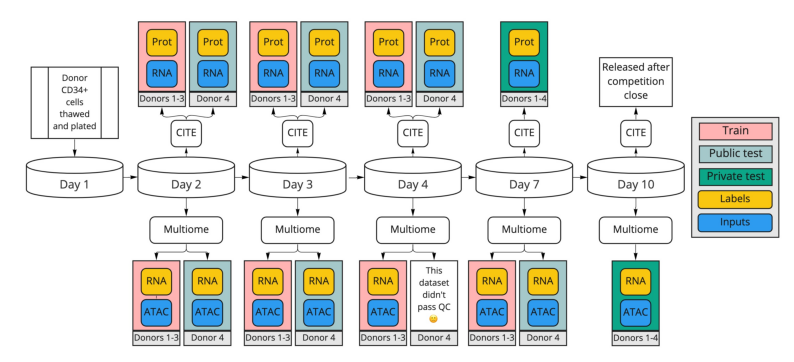

In [18]:
# Open and display
img = Image.open(DATA_DIR.joinpath("images", "multiome.jpg"))
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.show()



### Understanding how a single genome produces diverse cellular states is essential for deciphering the mechanisms of tissue function or dysfunction in health and disease. This study addresses this fundamental challenge in single-cell biology.

- The dataset consists of single-cell multiomics data from mobilized peripheral CD34+ hematopoietic stem and progenitor cells (HSPCs) obtained from four healthy human donors.
- At each sampling time point from each culture plate, cells were collected and analyzed using two single-cell assays: the 10x Chromium Single Cell Multiome ATAC + Gene Expression technology (Multiome) and the 10x Genomics Single Cell Gene Expression with Feature Barcoding technology, utilizing the TotalSeq™-B Human Universal Cocktail, V1.0 (CITE-seq).

### Assay Data Modalities

* **10x Chromium Single Cell Multiome ATAC + Gene Expression**

  1. **Chromatin accessibility** (epigenomic modality) via ATAC‑seq: measures which regions of the genome are in open (accessible) chromatin, reflecting putative regulatory elements (enhancers, promoters).
  2. **mRNA expression** (transcriptomic modality) via 3′‑end gene expression profiling: quantifies poly‑A transcripts in each cell.

* **10x Genomics Single Cell Gene Expression + TotalSeq™‑B Feature Barcoding (CITE‑seq)**

  1. **mRNA expression** (transcriptomic modality) via the same 3′‑end gene expression chemistry as above.
  2. **Surface protein abundance** (proteomic modality) via oligo‑conjugated antibodies (TotalSeq™‑B): each antibody carries a DNA barcode that’s sequenced alongside the transcriptome, giving you per‑cell counts for each targeted protein.

### ML Question Framing
- **Multiome**: Predict gene expression levels based on chromatin accessibility data.
- **CITE-seq**: Predict surface protein levels from gene expression data.

## ------ CITEseq MODEL ---------

### Data Preprocessing
- Load metadata and key features (mRNA levels of cell surface proteins).
- Apply dimension reduction using TruncatedSVD for sparse matrices.
- Reindex data for training.

In [4]:
#  Read in the metadata
metadata_df = pd.read_csv(DATA_DIR.joinpath("raw", "metadata.csv"),index_col='cell_id')
metadata_df = metadata_df[metadata_df.technology == "citeseq"]
metadata_df.head()

,day,donor,cell_type,technology
cell_id,,,,
c2150f55becb,2,27678,HSC,citeseq
65b7edf8a4da,2,27678,HSC,citeseq
c1b26cb1057b,2,27678,EryP,citeseq
917168fa6f83,2,27678,NeuP,citeseq
2b29feeca86d,2,27678,EryP,citeseq


In [7]:
# Load the important cols (cell surface protein) and constant cols (cols with no info)
with open(FP_IMPORTANT_COLS, "r") as f:
    important_cols = [line.strip() for line in f]

with open(FP_CONSTANT_COLS, 'r') as s:
    constant_cols = [line.strip() for line in s]

print("First 5 important columns:", important_cols[:5])
print("First 5 constant columns:", constant_cols[:5])

First 5 important columns: ['ENSG00000135218_CD36', 'ENSG00000010278_CD9', 'ENSG00000204287_HLA-DRA', 'ENSG00000117091_CD48', 'ENSG00000004468_CD38']
First 5 constant columns: ['ENSG00000003137_CYP26B1', 'ENSG00000004848_ARX', 'ENSG00000006606_CCL26', 'ENSG00000010379_SLC6A13', 'ENSG00000010932_FMO1']


In [8]:
# Boolean flag: if True, compute & save SVD; if False, load precomputed arrays
RUN_SVD = False

PROCESSED_DIR = DATA_DIR / "processed"
TRAIN_PKL = PROCESSED_DIR / "train_Citeseq_truncated_512.pkl"
TEST_PKL  = PROCESSED_DIR / "test_Citeseq_truncated_512.pkl"

# Read the raw cite training data
X_raw  = pd.read_hdf(DATA_DIR / "raw" / "train_cite_inputs.h5").drop(columns=constant_cols)

# Get the index, use it to arrange the metadata
cell_index = X_raw.index
meta = metadata_df.reindex(cell_index)

# Extract impotant cell surface proteins RNA expression levels
X0 = X_raw[important_cols].values

# Clean up the large file for mem management
del X_raw
gc.collect()

# Read test and convert to sparse matrix
Xt = pd.read_hdf(FP_CITE_TEST_INPUTS).drop(columns = constant_cols)
cell_index_test = Xt.index
meta_test = metadata_df.reindex(cell_index_test)
X0t = Xt[important_cols].values

del Xt
gc.collect()

# Normalize the data, fit on train and apply to both train and test
st = StandardScaler()
X0 = st.fit_transform(X0)
X0t = st.transform(X0t)

if RUN_SVD:
    print("Computing SVD embeddings...")
    # Dimension of SVD
    n_components = 512
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    # 1. Load raw, drop constant cols, reindex
    X_raw  = pd.read_hdf(DATA_DIR / "raw" / "train_cite_inputs.h5").drop(columns=constant_cols)
    Xt_raw = pd.read_hdf(DATA_DIR / "raw" / "test_cite_inputs.h5").drop(columns=constant_cols)

    # 2. Fit SVD on training, transform both
    X = svd.fit_transform(X_raw)
    Xt  = svd.transform(Xt_raw)

    # 3. Persist to disk
    PROCESSED_DIR.mkdir(exist_ok=True)
    with open(TRAIN_PKL, "wb") as f:
        pickle.dump(X, f)
    with open(TEST_PKL, "wb") as f:
        pickle.dump(Xt, f)

    # 4. Cleanup
    del X_raw, Xt_raw
    gc.collect()

    print(f"Computed and saved SVD embeddings X (512 PCs): {X.shape}, X_test: {Xt.shape}")


else:
    # Load precomputed embeddings
    with open(TRAIN_PKL, "rb") as f:
        X = pickle.load(f)
    with open(TEST_PKL, "rb") as f:
        Xt = pickle.load(f)

    print(f"Loaded precomputed SVD embeddings X (512 PCs): {X.shape}, X_test: {Xt.shape}")


Loaded precomputed SVD embeddings X (512 PCs): (70988, 512), X_test: (48663, 512)


### Target normalization
- Our target is the protein expression levels for each cell in the training set
- We will predict protein expression from RNA expression embeddings

In [11]:
# Load targets, our target is the protein expression levels for each cell in the training set
print(f'Reading CITE-seq targets from {FP_CITE_TRAIN_TARGETS}')
# Note: This file contains the protein expression levels for each cell in the training set
Y = pd.read_hdf(FP_CITE_TRAIN_TARGETS)

Y.head()

Reading CITE-seq targets from /share/crsp/lab/pkaiser/ddlin/single-cell-multimodal-ml/data/raw/train_cite_targets.h5


gene_id,CD86,CD274,CD270,CD155,CD112,CD47,CD48,CD40,CD154,CD52,...,CD94,CD162,CD85j,CD23,CD328,HLA-E,CD82,CD101,CD88,CD224
cell_id,,,,,,,,,,,,,,,,,,,,,
45006fe3e4c8,1.167804,0.622530,0.106959,0.324989,3.331674,6.426002,1.480766,-0.728392,-0.468851,-0.073285,...,-0.448390,3.220174,-0.533004,0.674956,-0.006187,0.682148,1.398105,0.414292,1.780314,0.548070
d02759a80ba2,0.818970,0.506009,1.078682,6.848758,3.524885,5.279456,4.930438,2.069372,0.333652,-0.468088,...,0.323613,8.407108,0.131301,0.047607,-0.243628,0.547864,1.832587,0.982308,2.736507,2.184063
c016c6b0efa5,-0.356703,-0.422261,-0.824493,1.137495,0.518924,7.221962,-0.375034,1.738071,0.142919,-0.971460,...,1.348692,4.888579,-0.279483,-0.131097,-0.177604,-0.689188,9.013709,-1.182975,3.958148,2.868600
ba7f733a4f75,-1.201507,0.149115,2.022468,6.021595,7.258670,2.792436,21.708519,-0.137913,1.649969,-0.754680,...,1.504426,12.391979,0.511394,0.587863,-0.752638,1.714851,3.893782,1.799661,1.537249,4.407671
fbcf2443ffb2,-0.100404,0.697461,0.625836,-0.298404,1.369898,3.254521,-1.659380,0.643531,0.902710,1.291877,...,0.777023,6.496499,0.279898,-0.841950,-0.869419,0.675092,5.259685,-0.835379,9.631781,1.765445


In [12]:
# Normalize Y by subtracting the mean and dividing by the standard deviation for each cell
# This is important for training stability and performance
Y = Y.values
Y -= Y.mean(axis=1).reshape(-1, 1)
Y /= Y.std(axis=1).reshape(-1, 1)
Y.shape

(70988, 140)

### Let's keep only some features

In [ ]:
# Concatenate the X with 75 SVD embeddings and X0 with selected cell surface proteins RNA expression levels
# These are information from RNA Expression
X = np.hstack((X[:,:75],X0))
X.shape

(70988, 159)

### Tensorflow Keras librairies

In [14]:
import math

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, LearningRateScheduler, EarlyStopping
from tensorflow.keras.layers import Dense, Input, Concatenate, Dropout, BatchNormalization

# Check if GPU is available
if tf.config.list_physical_devices('GPU'):
    print("GPU is available")
else:
    print("GPU is not available, using CPU")

2025-07-22 18:53:53.876489: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-22 18:53:54.439562: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-22 18:53:54.602645: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753235634.721339 3305803 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753235634.741439 3305803 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753235635.241123 3305803 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

GPU is not available, using CPU


2025-07-22 18:54:02.545338: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Metric and loss function

In [15]:
def correlation_score(y_true, y_pred):
    """
    Compute the mean Pearson correlation coefficient between true and predicted values.

    Parameters:
    - y_true: Ground truth values (numpy array or pandas DataFrame) of shape (n_samples, n_targets).
    - y_pred: Predicted values (numpy array or pandas DataFrame) of shape (n_samples, n_targets).

    Returns:
    - float: Mean Pearson correlation coefficient across all samples.
    """
    # Convert pandas DataFrame to numpy array if needed
    if type(y_true) == pd.DataFrame:
        y_true = y_true.values
    if type(y_pred) == pd.DataFrame:
        y_pred = y_pred.values
    
    corrsum = 0  # Initialize sum of correlation coefficients
    # Iterate over each sample (row) to compute correlation
    for i in range(len(y_true)):
        # Calculate Pearson correlation coefficient for the i-th sample
        # np.corrcoef returns a 2x2 matrix; [1,0] is the off-diagonal (true vs. pred)
        corrsum += np.corrcoef(y_true[i], y_pred[i])[1, 0]
    
    # Return the mean correlation across all samples
    return corrsum / len(y_true)

def negative_correlation_loss(y_true, y_pred):
    """
    Custom Keras loss function to compute the negative mean Pearson correlation coefficient.

    Parameters:
    - y_true: Ground truth tensor of shape (batch_size, n_targets).
    - y_pred: Predicted tensor of shape (batch_size, n_targets).

    Returns:
    - Tensor: Negative mean Pearson correlation coefficient (to be minimized).
    """
    # Compute mean of predictions across features (axis=1) for each sample
    my = K.mean(tf.convert_to_tensor(y_pred), axis=1)
    
    # Reshape mean to (batch_size, 1) and tile to match y_true shape (batch_size, n_targets)
    my = tf.tile(tf.expand_dims(my, axis=1), (1, y_true.shape[1]))
    
    # Center predictions by subtracting the mean (y_pred - mean(y_pred))
    ym = y_pred - my
    
    # Numerator: Sum of element-wise product of true and centered predicted values
    r_num = K.sum(tf.multiply(y_true, ym), axis=1)
    
    # Denominator: Product of standard deviation of predictions and sqrt(n_targets)
    r_den = tf.sqrt(K.sum(K.square(ym), axis=1) * float(y_true.shape[-1]))
    
    # Compute mean Pearson correlation coefficient across the batch
    r = tf.reduce_mean(r_num / r_den)
    
    # Return negative correlation (to minimize as a loss)
    return -r

### Model and Parameters
- A basic "wide-and-deep" MLP model.
- Hyperparameters optimized using Keras Tuner.
- Further architectural options could be investigated.
- We aim to predict protein expression from RNA expression data.

In [16]:
LR_START = 0.01
BATCH_SIZE = 512

def create_model():
    # regularizers & dropout rate
    reg1 = 9.613e-06
    reg2 = 1e-07
    REG1 = tf.keras.regularizers.l2(reg1)
    REG2 = tf.keras.regularizers.l2(reg2)
    DROP = 0.1

    activation = 'selu'
    inputs = Input(shape=(X.shape[1],))

    # four successive Dense→Dropout blocks
    x0 = Dense(256, kernel_regularizer=REG1, activation=activation)(inputs)
    x0 = Dropout(DROP)(x0)

    x1 = Dense(512, kernel_regularizer=REG1, activation=activation)(x0)
    x1 = Dropout(DROP)(x1)

    x2 = Dense(512, kernel_regularizer=REG1, activation=activation)(x1)
    x2 = Dropout(DROP)(x2)

    x3 = Dense(Y.shape[1], kernel_regularizer=REG1, activation=activation)(x2)
    x3 = Dropout(DROP)(x3)

    # concatenate all four intermediate outputs
    x = Concatenate()([x0, x1, x2, x3])

    # final linear layer to produce Y.shape[1] outputs
    x = Dense(Y.shape[1], kernel_regularizer=REG2, activation='linear')(x)

    return Model(inputs, x)

test_model = create_model()
test_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 159)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     40,960 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │    131,584 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    262,656 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 140)       │     71,820 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 140)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1420)      │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0],  │
│                     │                   │            │ dropout_2[0][0],  │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 140)       │    198,940 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 705,960 (2.69 MB)

 Trainable params: 705,960 (2.69 MB)

 Non-trainable params: 0 (0.00 B)

### Training

-  The correlation scores (~0.89 per fold and ~0.89 for out of fold) suggest the model is performing well for using the embedded RNA expression information to predict protein expression.

In [ ]:
%%time

# Create the model dir
model_dir = DATA_DIR.joinpath("models", "citeseq", "submissions")
model_dir.mkdir(parents=True, exist_ok=True)

# Also create the directory for weights 
weights_dir = DATA_DIR.joinpath("models", "citeseq")
weights_dir.mkdir(parents=True, exist_ok=True)

EPOCHS = 300 
N_SPLITS = 3

pred_train = np.zeros((Y.shape[0],Y.shape[1]))

np.random.seed(1)
tf.random.set_seed(1)
score_list = []
kf = GroupKFold(n_splits=N_SPLITS)
score_list = []

# GroupKFold to ensure that cells from the same donor are not in both train and validation sets, preventing data leakage
# This way, we can ensure that the model generalizes well to unseen data
for fold, (idx_tr, idx_va) in enumerate(kf.split(X, groups=meta.donor)):
    start_time = datetime.datetime.now()
    model = None
    gc.collect()
    
    X_tr = X[idx_tr]
    y_tr = Y[idx_tr]
    X_va = X[idx_va]
    y_va = Y[idx_va]

    lr = ReduceLROnPlateau(
                    monitor = "val_loss",
                    factor = 0.9, 
                    patience = 4, 
                    verbose = VERBOSE)

    es = EarlyStopping(
                    monitor = "val_loss",
                    patience = 40, 
                    verbose = VERBOSE,
                    mode = "min", 
                    restore_best_weights = True)

    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
                    filepath = weights_dir.joinpath("citeseq.weights.h5"),
                    save_weights_only = True,
                    monitor = 'val_loss',
                    mode = 'min',
                    save_best_only = True)

    callbacks = [
                    lr, 
                    es, 
                    model_checkpoint_callback
                    ]
    
    model = create_model()
    
    model.compile(
                optimizer = tf.keras.optimizers.Adam(learning_rate=LR_START),
                metrics = [negative_correlation_loss],
                loss = negative_correlation_loss
                 )
    # Training
    model.fit(
                X_tr,
                y_tr, 
                validation_data=(
                                X_va,
                                y_va), 
                epochs = EPOCHS,
                verbose = VERBOSE,
                batch_size = BATCH_SIZE,
                shuffle = True,
                callbacks = callbacks)

    del X_tr, y_tr 
    gc.collect()
    
    model.load_weights(weights_dir.joinpath("citeseq.weights.h5"))
    model.save(model_dir.joinpath(f"model_{fold}.keras"))
    print('model saved')
    
    #  Model validation
    y_va_pred = model.predict(X_va)
    corrscore = correlation_score(y_va, y_va_pred)
    pred_train[idx_va] = y_va_pred
    
    print(f"Fold {fold}, correlation =  {corrscore:.5f}")
    del X_va, y_va, y_va_pred
    gc.collect()
    score_list.append(corrscore)

# Show overall score
print(f"{Fore.GREEN}{Style.BRIGHT}Mean correlation = {np.array(score_list).mean():.5f}{Style.RESET_ALL}")
score_total = correlation_score(Y, pred_train)
print(f"{Fore.BLUE}{Style.BRIGHT}Out of fold correlation = {score_total:.5f}{Style.RESET_ALL}")

model saved
776/776 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Fold 0, correlation =  0.89081
model saved
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Fold 1, correlation =  0.89672
model saved
694/694 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Fold 2, correlation =  0.89311
Mean correlation = 0.89355
Out of fold correlation = 0.89353
CPU times: user 1h 56min 21s, sys: 8min 18s, total: 2h 4min 40s
Wall time: 15min 26s


### **Modeling & Training**
A "wide-and-deep" Multi-Layer Perceptron (MLP) model was constructed using TensorFlow and Keras. The model architecture consists of several dense and dropout layers, with the final output predicting the levels of 140 surface proteins.

Key aspects of the model and training process are:
* **Loss Function**: The model is optimized using a `negative_correlation_loss` function, which aims to maximize the Pearson correlation between true and predicted values.
* **Evaluation Metric**: The primary metric for success is the `correlation_score`, which calculates the mean Pearson correlation coefficient.
* **Training**: The model is trained using a 3-fold cross-validation strategy grouped by donor to prevent data leakage and ensure generalization. The training process includes callbacks like `ReduceLROnPlateau` for adjusting the learning rate and `EarlyStopping` to prevent overfitting.

### **Results**
- The model demonstrates strong performance, achieving a mean out-of-fold correlation score of approximately **0.89**, indicating a high degree of accuracy in predicting protein expression from RNA expression data.

### Appendix: Data Detailes
- **Multiome**
  - **train/test_multi_inputs.h5**: ATAC-seq peak counts processed with TF-IDF transformation using the standard log(TF) * log(IDF) output (chromatin accessibility). Rows represent cells, and columns correspond to genomic locations, identified by coordinates on the GRCh38 reference genome from 10x References - 2020-A (July 7, 2020).
  - **train_multi_targets.h5**: RNA gene expression levels, normalized by library size and log1p transformed, for the same cells.
- **CITE-seq**
  - **train/test_cite_inputs.h5**: RNA gene expression levels, normalized by library size and log1p transformed. Rows represent cells, and columns correspond to genes, labeled as {gene_name}_{gene_ensemble-ids}.
  - **train_cite_targets.h5**: Surface protein levels for the same cells, normalized using the DSB method.

In [ ]:
# FP_SUBMISSION         = RAW_DIR.joinpath("sample_submission.csv")